# Advertisement Effectiveness Analysis

This notebook analyzes advertisement effectiveness using four datasets:
1. Social_Media_Advertising.csv
2. marketing_campaign_dataset.csv
3. Advertising_Data.csv
4. advertising.csv

We'll perform comprehensive analysis including:
- ROI/Conversion rates analysis
- Customer engagement metrics
- Demographic analysis
- Channel performance comparison
- Advertising success prediction system

## 1. Import Necessary Libraries

In [1]:
# Data manipulation libraries
import pandas as pd
import numpy as np

# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Machine learning libraries
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# ML models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor

# Statistical analysis
from scipy import stats

# Settings for better visualizations
plt.style.use('seaborn-v0_8-whitegrid')
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Display all columns
pd.set_option('display.max_columns', None)

## 2. Load and Explore Datasets

In [2]:
# Load all datasets
social_media_df = pd.read_csv('Social_Media_Advertising.csv')
marketing_campaign_df = pd.read_csv('marketing_campaign_dataset.csv')
advertising_data_df = pd.read_csv('Advertising_Data.csv')
advertising_df = pd.read_csv('advertising.csv')

# Display basic information about each dataset
print("\nSocial Media Advertising Dataset:")
print(f"Shape: {social_media_df.shape}")
social_media_df.head()


Social Media Advertising Dataset:
Shape: (300000, 16)


,Campaign_ID,Target_Audience,Campaign_Goal,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date,Company
0,529013,Men 35-44,Product Launch,15 Days,Instagram,0.15,$500.00,5.790000,Las Vegas,Spanish,500,3000,7,Health,2022-02-25,Aura Align
1,275352,Women 45-60,Market Expansion,15 Days,Facebook,0.01,$500.00,7.210000,Los Angeles,French,500,3000,5,Home,2022-05-12,Hearth Harmony
2,692322,Men 45-60,Product Launch,15 Days,Instagram,0.08,$500.00,0.430000,Austin,Spanish,500,3000,9,Technology,2022-06-19,Cyber Circuit
3,675757,Men 25-34,Increase Sales,15 Days,Pinterest,0.03,$500.00,0.909824,Miami,Spanish,293,1937,1,Health,2022-09-08,Well Wish
4,535900,Men 45-60,Market Expansion,15 Days,Pinterest,0.13,$500.00,1.422828,Austin,French,293,1937,1,Home,2022-08-24,Hearth Harmony


In [3]:
print("\nMarketing Campaign Dataset:")
print(f"Shape: {marketing_campaign_df.shape}")
marketing_campaign_df.head()


Marketing Campaign Dataset:
Shape: (200000, 16)


,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,"$16,174.00",6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,"$11,566.00",5.61,New York,German,116,7523,7,Fashionistas,2021-01-02
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,"$10,200.00",7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,"$12,724.00",5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,"$16,452.00",6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05


In [4]:
print("\nAdvertising Data Dataset:")
print(f"Shape: {advertising_data_df.shape}")
advertising_data_df.head()


Advertising Data Dataset:
Shape: (300, 7)


,TV,Billboards,Google_Ads,Social_Media,Influencer_Marketing,Affiliate_Marketing,Product_Sold
0,281.42,538.80,123.94,349.30,242.77,910.10,7164.0
1,702.97,296.53,558.13,180.55,781.06,132.43,5055.0
2,313.14,295.94,642.96,505.71,438.91,464.23,6154.0
3,898.52,61.27,548.73,240.93,278.96,432.27,5480.0
4,766.52,550.72,651.91,666.33,396.33,841.93,9669.0


In [5]:
print("\nAdvertising Dataset:")
print(f"Shape: {advertising_df.shape}")
advertising_df.head()


Advertising Dataset:
Shape: (200, 4)


,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


### 2.1 Data Cleaning and Preprocessing

In [6]:
# Function to check for missing values
def check_missing_values(df, title):
    missing = df.isnull().sum()
    missing_percent = (missing / len(df)) * 100
    missing_df = pd.DataFrame({'Missing Values': missing, 'Percentage': missing_percent})
    missing_df = missing_df[missing_df['Missing Values'] > 0].sort_values('Missing Values', ascending=False)
    
    print(f"\n{title} - Missing Values:")
    if len(missing_df) > 0:
        print(missing_df)
    else:
        print("No missing values found.")
    return missing_df

# Check missing values in all datasets
check_missing_values(social_media_df, "Social Media Advertising")
check_missing_values(marketing_campaign_df, "Marketing Campaign")
check_missing_values(advertising_data_df, "Advertising Data")
check_missing_values(advertising_df, "Advertising")


Social Media Advertising - Missing Values:
No missing values found.

Marketing Campaign - Missing Values:
No missing values found.

Advertising Data - Missing Values:
No missing values found.

Advertising - Missing Values:
No missing values found.


,Missing Values,Percentage


In [7]:
# Clean and preprocess Social Media Advertising dataset
def clean_social_media_df(df):
    df_clean = df.copy()
    
    # Convert Acquisition_Cost to numeric by removing '$' and converting to float
    df_clean['Acquisition_Cost'] = df_clean['Acquisition_Cost'].str.replace('$', '').astype(float)
    
    # Extract age ranges from Target_Audience
    df_clean['Gender'] = df_clean['Target_Audience'].str.split(' ').str[0]
    df_clean['Age_Range'] = df_clean['Target_Audience'].str.split(' ').str[1]
    
    # Convert Date to datetime
    df_clean['Date'] = pd.to_datetime(df_clean['Date'])
    
    # Extract duration as numeric
    df_clean['Duration_Days'] = df_clean['Duration'].str.split(' ').str[0].astype(int)
    
    return df_clean

# Clean and preprocess Marketing Campaign dataset
def clean_marketing_campaign_df(df):
    df_clean = df.copy()
    
    # Convert Acquisition_Cost to numeric by removing '$', ',' and converting to float
    df_clean['Acquisition_Cost'] = df_clean['Acquisition_Cost'].str.replace('$', '').str.replace(',', '').astype(float)
    
    # Extract age ranges from Target_Audience
    df_clean['Gender'] = df_clean['Target_Audience'].str.split(' ').str[0]
    df_clean['Age_Range'] = df_clean['Target_Audience'].str.split(' ').str[1]
    
    # Convert Date to datetime
    df_clean['Date'] = pd.to_datetime(df_clean['Date'])
    
    # Extract duration as numeric
    df_clean['Duration_Days'] = df_clean['Duration'].str.split(' ').str[0].astype(int)
    
    return df_clean

# Apply cleaning functions
social_media_df_clean = clean_social_media_df(social_media_df)
marketing_campaign_df_clean = clean_marketing_campaign_df(marketing_campaign_df)

# Display cleaned datasets
print("\nCleaned Social Media Advertising Dataset:")
social_media_df_clean.head()


Cleaned Social Media Advertising Dataset:


,Campaign_ID,Target_Audience,Campaign_Goal,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date,Company,Gender,Age_Range,Duration_Days
0,529013,Men 35-44,Product Launch,15 Days,Instagram,0.15,500.0,5.790000,Las Vegas,Spanish,500,3000,7,Health,2022-02-25,Aura Align,Men,35-44,15
1,275352,Women 45-60,Market Expansion,15 Days,Facebook,0.01,500.0,7.210000,Los Angeles,French,500,3000,5,Home,2022-05-12,Hearth Harmony,Women,45-60,15
2,692322,Men 45-60,Product Launch,15 Days,Instagram,0.08,500.0,0.430000,Austin,Spanish,500,3000,9,Technology,2022-06-19,Cyber Circuit,Men,45-60,15
3,675757,Men 25-34,Increase Sales,15 Days,Pinterest,0.03,500.0,0.909824,Miami,Spanish,293,1937,1,Health,2022-09-08,Well Wish,Men,25-34,15
4,535900,Men 45-60,Market Expansion,15 Days,Pinterest,0.13,500.0,1.422828,Austin,French,293,1937,1,Home,2022-08-24,Hearth Harmony,Men,45-60,15


In [8]:
print("\nCleaned Marketing Campaign Dataset:")
marketing_campaign_df_clean.head()


Cleaned Marketing Campaign Dataset:


,Campaign_ID,Company,Campaign_Type,Target_Audience,Duration,Channel_Used,Conversion_Rate,Acquisition_Cost,ROI,Location,Language,Clicks,Impressions,Engagement_Score,Customer_Segment,Date,Gender,Age_Range,Duration_Days
0,1,Innovate Industries,Email,Men 18-24,30 days,Google Ads,0.04,16174.0,6.29,Chicago,Spanish,506,1922,6,Health & Wellness,2021-01-01,Men,18-24,30
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,11566.0,5.61,New York,German,116,7523,7,Fashionistas,2021-01-02,Women,35-44,60
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,10200.0,7.18,Los Angeles,French,584,7698,1,Outdoor Adventurers,2021-01-03,Men,25-34,30
3,4,DataTech Solutions,Display,All Ages,60 days,YouTube,0.11,12724.0,5.55,Miami,Mandarin,217,1820,7,Health & Wellness,2021-01-04,All,Ages,60
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,16452.0,6.50,Los Angeles,Mandarin,379,4201,3,Health & Wellness,2021-01-05,Men,25-34,15


## 3. Exploratory Data Analysis (EDA)

### 3.1 Statistical Summary

In [9]:
# Statistical summary for all datasets
print("\nSocial Media Advertising - Statistical Summary:")
social_media_df_clean.describe(include='all').T



Social Media Advertising - Statistical Summary:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Campaign_ID,300000.0,NaN,NaN,NaN,550444.804487,100001.0,325003.5,551164.5,776284.5,999998.0,260252.586037
Target_Audience,300000,9,Women 18-24,33593,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Campaign_Goal,300000,4,Brand Awareness,75248,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Duration,300000,4,15 Days,75000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Channel_Used,300000,4,Facebook,75164,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Conversion_Rate,300000.0,NaN,NaN,NaN,0.080009,0.01,0.05,0.08,0.11,0.15,0.040563
Acquisition_Cost,300000.0,NaN,NaN,NaN,7753.750796,500.0,4121.915,7755.9,11385.075,15000.0,4301.035148
ROI,300000.0,NaN,NaN,NaN,3.177691,0.0,0.93,2.67,5.33,8.0,2.4612
Location,300000,5,Los Angeles,60322,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Language,300000,3,English,100116,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
print("\nMarketing Campaign - Statistical Summary:")
marketing_campaign_df_clean.describe(include='all').T


Marketing Campaign - Statistical Summary:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Campaign_ID,200000.0,NaN,NaN,NaN,100000.5,1.0,50000.75,100000.5,150000.25,200000.0,57735.171256
Company,200000,5,TechCorp,40237,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Campaign_Type,200000,5,Influencer,40169,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Target_Audience,200000,5,Men 18-24,40258,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Duration,200000,4,30 days,50255,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Channel_Used,200000,6,Email,33599,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Conversion_Rate,200000.0,NaN,NaN,NaN,0.08007,0.01,0.05,0.08,0.12,0.15,0.040602
Acquisition_Cost,200000.0,NaN,NaN,NaN,12504.39304,5000.0,8739.75,12496.5,16264.0,20000.0,4337.664545
ROI,200000.0,NaN,NaN,NaN,5.002438,2.0,3.5,5.01,6.51,8.0,1.734488
Location,200000,5,Miami,40269,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
print("\nAdvertising Data - Statistical Summary:")
advertising_data_df.describe().T


Advertising Data - Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
TV,300.0,517.431000,288.114792,1.04,273.0900,513.970,774.2750,998.10
Billboards,300.0,502.644933,275.842369,3.63,277.9125,533.020,745.0050,995.32
Google_Ads,300.0,512.444133,285.422376,14.86,250.5300,528.965,763.3450,999.23
Social_Media,300.0,489.800100,273.883915,11.69,265.6125,486.385,695.1175,996.16
Influencer_Marketing,300.0,465.732567,288.314080,0.77,214.4800,480.355,703.0925,999.83
Affiliate_Marketing,300.0,484.430633,277.955458,6.74,267.6775,451.315,721.0650,987.58
Product_Sold,300.0,7031.523333,1703.614951,2259.00,5922.5000,7051.000,8278.0000,12227.00


In [12]:
print("\nAdvertising - Statistical Summary:")
advertising_df.describe().T


Advertising - Statistical Summary:


,count,mean,std,min,25%,50%,75%,max
TV,200.0,147.0425,85.854236,0.7,74.375,149.75,218.825,296.4
Radio,200.0,23.2640,14.846809,0.0,9.975,22.90,36.525,49.6
Newspaper,200.0,30.5540,21.778621,0.3,12.750,25.75,45.100,114.0
Sales,200.0,15.1305,5.283892,1.6,11.000,16.00,19.050,27.0


### 3.2 ROI/Conversion Rates Analysis

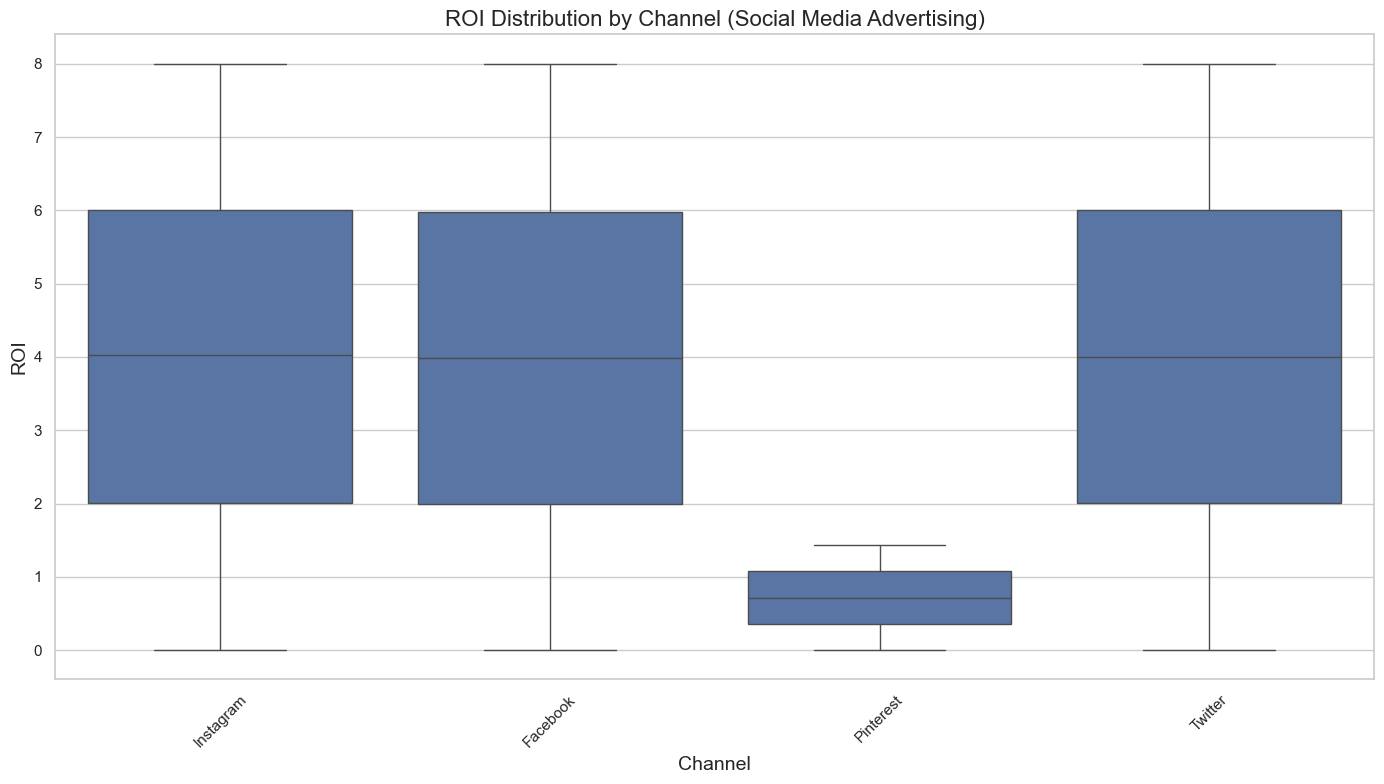

In [13]:
# ROI Analysis for Social Media Advertising
plt.figure(figsize=(14, 8))
sns.boxplot(x='Channel_Used', y='ROI', data=social_media_df_clean)
plt.title('ROI Distribution by Channel (Social Media Advertising)', fontsize=16)
plt.xlabel('Channel', fontsize=14)
plt.ylabel('ROI', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

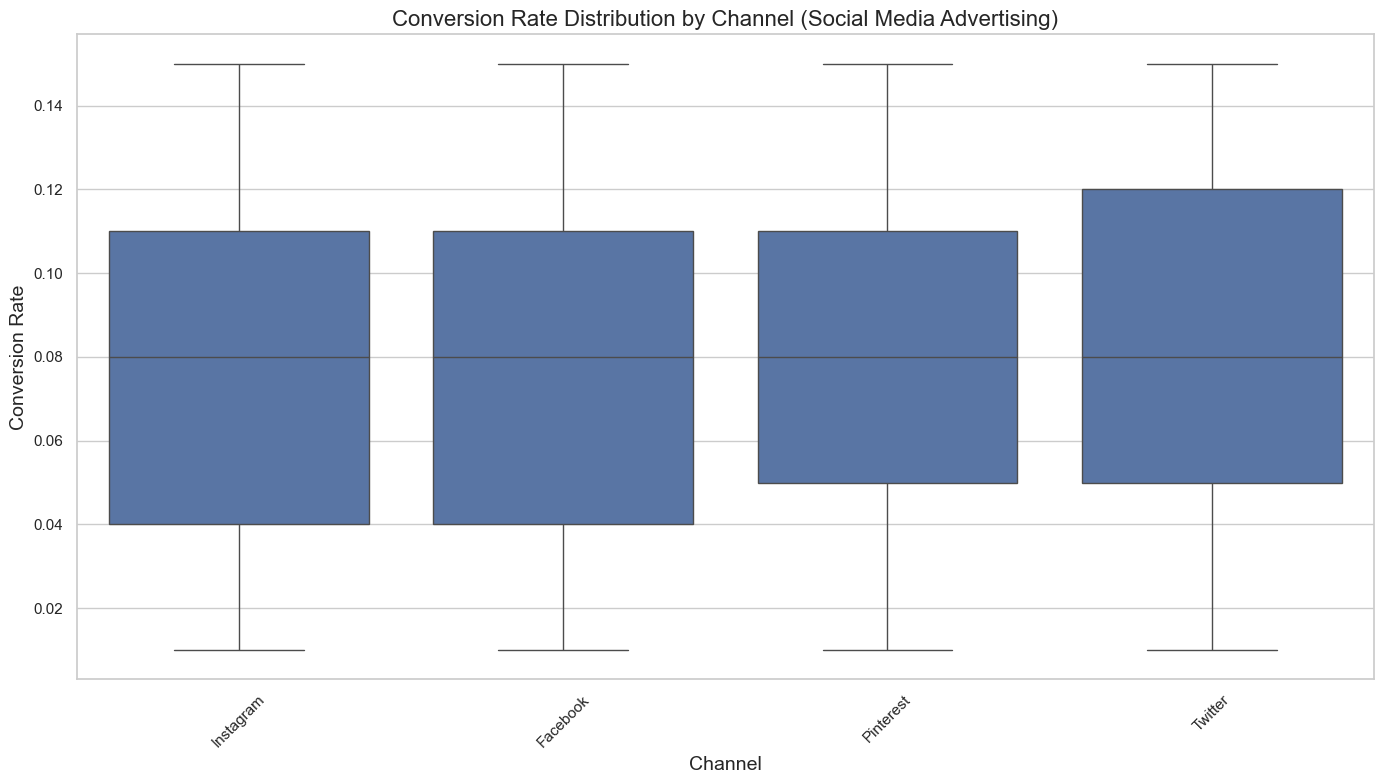

In [14]:
# Conversion Rate Analysis for Social Media Advertising
plt.figure(figsize=(14, 8))
sns.boxplot(x='Channel_Used', y='Conversion_Rate', data=social_media_df_clean)
plt.title('Conversion Rate Distribution by Channel (Social Media Advertising)', fontsize=16)
plt.xlabel('Channel', fontsize=14)
plt.ylabel('Conversion Rate', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

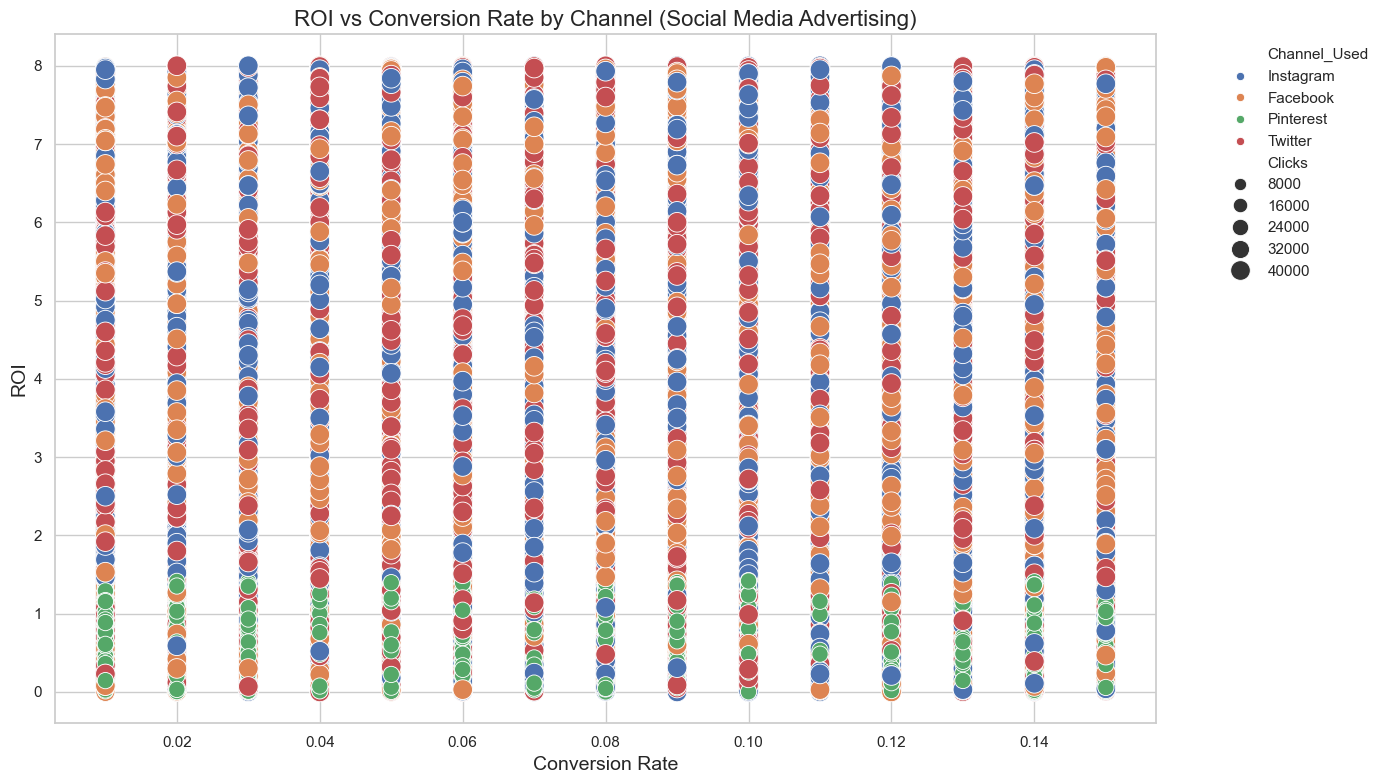

In [15]:
# ROI vs Conversion Rate Scatter Plot with Channel coloring
plt.figure(figsize=(14, 8))
sns.scatterplot(x='Conversion_Rate', y='ROI', hue='Channel_Used', 
                size='Clicks', sizes=(50, 200), data=social_media_df_clean)
plt.title('ROI vs Conversion Rate by Channel (Social Media Advertising)', fontsize=16)
plt.xlabel('Conversion Rate', fontsize=14)
plt.ylabel('ROI', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# Interactive ROI Analysis for Marketing Campaign
fig = px.box(marketing_campaign_df_clean, x='Campaign_Type', y='ROI', 
             color='Channel_Used', title='ROI by Campaign Type and Channel')
fig.update_layout(height=600, width=900)
fig.show()

In [ ]:
# ROI vs Acquisition Cost Analysis
fig = px.scatter(marketing_campaign_df_clean, x='Acquisition_Cost', y='ROI', 
                 color='Campaign_Type', size='Clicks', hover_data=['Company', 'Conversion_Rate'],
                 title='ROI vs Acquisition Cost by Campaign Type')
fig.update_layout(height=600, width=900)
fig.show()

### 3.3 Customer Engagement Metrics Analysis

In [ ]:
# Engagement Score Analysis for Social Media Advertising
plt.figure(figsize=(14, 8))
sns.boxplot(x='Channel_Used', y='Engagement_Score', data=social_media_df_clean)
plt.title('Engagement Score Distribution by Channel (Social Media Advertising)', fontsize=16)
plt.xlabel('Channel', fontsize=14)
plt.ylabel('Engagement Score', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Clicks vs Impressions Analysis
plt.figure(figsize=(14, 8))
sns.scatterplot(x='Impressions', y='Clicks', hue='Channel_Used', 
                size='Engagement_Score', sizes=(50, 200), data=social_media_df_clean)
plt.title('Clicks vs Impressions by Channel (Social Media Advertising)', fontsize=16)
plt.xlabel('Impressions', fontsize=14)
plt.ylabel('Clicks', fontsize=14)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# Calculate Click-Through Rate (CTR)
social_media_df_clean['CTR'] = social_media_df_clean['Clicks'] / social_media_df_clean['Impressions']
marketing_campaign_df_clean['CTR'] = marketing_campaign_df_clean['Clicks'] / marketing_campaign_df_clean['Impressions']

# CTR Analysis by Channel
plt.figure(figsize=(14, 8))
sns.barplot(x='Channel_Used', y='CTR', data=social_media_df_clean)
plt.title('Click-Through Rate (CTR) by Channel (Social Media Advertising)', fontsize=16)
plt.xlabel('Channel', fontsize=14)
plt.ylabel('CTR', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Interactive Engagement Analysis for Marketing Campaign
fig = px.scatter(marketing_campaign_df_clean, x='Impressions', y='Clicks', 
                 color='Channel_Used', size='Engagement_Score', 
                 hover_data=['Company', 'Campaign_Type', 'CTR'],
                 title='Engagement Metrics by Channel (Marketing Campaign)')
fig.update_layout(height=600, width=900)
fig.show()

### 3.4 Demographic Analysis

In [ ]:
# Gender Distribution Analysis
plt.figure(figsize=(12, 6))
sns.countplot(x='Gender', data=social_media_df_clean)
plt.title('Gender Distribution in Advertising Campaigns', fontsize=16)
plt.xlabel('Gender', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Age Range Distribution Analysis
plt.figure(figsize=(14, 6))
sns.countplot(x='Age_Range', data=social_media_df_clean)
plt.title('Age Range Distribution in Advertising Campaigns', fontsize=16)
plt.xlabel('Age Range', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# ROI by Gender and Age Range
plt.figure(figsize=(16, 8))
sns.boxplot(x='Age_Range', y='ROI', hue='Gender', data=social_media_df_clean)
plt.title('ROI Distribution by Gender and Age Range', fontsize=16)
plt.xlabel('Age Range', fontsize=14)
plt.ylabel('ROI', fontsize=14)
plt.legend(title='Gender')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Conversion Rate by Gender and Age Range
plt.figure(figsize=(16, 8))
sns.boxplot(x='Age_Range', y='Conversion_Rate', hue='Gender', data=social_media_df_clean)
plt.title('Conversion Rate Distribution by Gender and Age Range', fontsize=16)
plt.xlabel('Age Range', fontsize=14)
plt.ylabel('Conversion Rate', fontsize=14)
plt.legend(title='Gender')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# Interactive Demographic Analysis
fig = px.sunburst(social_media_df_clean, path=['Gender', 'Age_Range', 'Channel_Used'], 
                  values='Clicks', color='Conversion_Rate',
                  title='Demographic Breakdown of Advertising Campaigns')
fig.update_layout(height=700, width=700)
fig.show()

### 3.5 Channel Performance Comparison

In [ ]:
# Channel Performance Analysis - Social Media Advertising
channel_performance = social_media_df_clean.groupby('Channel_Used').agg({
    'ROI': 'mean',
    'Conversion_Rate': 'mean',
    'Acquisition_Cost': 'mean',
    'Clicks': 'sum',
    'Impressions': 'sum',
    'Engagement_Score': 'mean',
    'CTR': 'mean'
}).reset_index()

# Calculate Cost Per Click (CPC)
channel_performance['CPC'] = channel_performance['Acquisition_Cost'] / channel_performance['Clicks']

# Display channel performance metrics
channel_performance.sort_values('ROI', ascending=False)

In [ ]:
# Visualize Channel Performance - ROI and Conversion Rate
fig, ax1 = plt.subplots(figsize=(14, 8))

# Plot ROI bars
sns.barplot(x='Channel_Used', y='ROI', data=channel_performance, ax=ax1, color='skyblue')
ax1.set_xlabel('Channel', fontsize=14)
ax1.set_ylabel('ROI', fontsize=14, color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)

# Create second y-axis for Conversion Rate
ax2 = ax1.twinx()
sns.lineplot(x='Channel_Used', y='Conversion_Rate', data=channel_performance, ax=ax2, color='red', marker='o', linewidth=2)
ax2.set_ylabel('Conversion Rate', fontsize=14, color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Channel Performance: ROI vs Conversion Rate', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# Visualize Channel Performance - Engagement Metrics
fig, ax1 = plt.subplots(figsize=(14, 8))

# Plot CTR bars
sns.barplot(x='Channel_Used', y='CTR', data=channel_performance, ax=ax1, color='green')
ax1.set_xlabel('Channel', fontsize=14)
ax1.set_ylabel('CTR', fontsize=14, color='green')
ax1.tick_params(axis='y', labelcolor='green')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45)

# Create second y-axis for Engagement Score
ax2 = ax1.twinx()
sns.lineplot(x='Channel_Used', y='Engagement_Score', data=channel_performance, ax=ax2, color='purple', marker='o', linewidth=2)
ax2.set_ylabel('Engagement Score', fontsize=14, color='purple')
ax2.tick_params(axis='y', labelcolor='purple')

plt.title('Channel Performance: CTR vs Engagement Score', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# Interactive Channel Performance Comparison
fig = make_subplots(rows=2, cols=2, 
                    subplot_titles=('ROI by Channel', 'Conversion Rate by Channel', 
                                   'CPC by Channel', 'Engagement Score by Channel'))

# ROI by Channel
fig.add_trace(go.Bar(x=channel_performance['Channel_Used'], y=channel_performance['ROI'], name='ROI'), row=1, col=1)

# Conversion Rate by Channel
fig.add_trace(go.Bar(x=channel_performance['Channel_Used'], y=channel_performance['Conversion_Rate'], name='Conversion Rate'), row=1, col=2)

# CPC by Channel
fig.add_trace(go.Bar(x=channel_performance['Channel_Used'], y=channel_performance['CPC'], name='CPC'), row=2, col=1)

# Engagement Score by Channel
fig.add_trace(go.Bar(x=channel_performance['Channel_Used'], y=channel_performance['Engagement_Score'], name='Engagement Score'), row=2, col=2)

fig.update_layout(height=800, width=1000, title_text='Channel Performance Metrics Comparison')
fig.show()

### 3.6 Analysis of Traditional Advertising Data

In [ ]:
# Correlation Analysis for Advertising Data
plt.figure(figsize=(12, 10))
correlation = advertising_data_df.corr()
mask = np.triu(correlation)
sns.heatmap(correlation, annot=True, cmap='coolwarm', mask=mask, vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Matrix for Advertising Data', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# Pairplot for Advertising Data
sns.pairplot(advertising_data_df, height=2.5)
plt.suptitle('Pairplot of Advertising Data Variables', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# Correlation Analysis for Simple Advertising Dataset
plt.figure(figsize=(10, 8))
correlation = advertising_df.corr()
mask = np.triu(correlation)
sns.heatmap(correlation, annot=True, cmap='coolwarm', mask=mask, vmin=-1, vmax=1, fmt='.2f')
plt.title('Correlation Matrix for Advertising Dataset', fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# Pairplot for Simple Advertising Dataset
sns.pairplot(advertising_df, height=2.5)
plt.suptitle('Pairplot of Advertising Variables', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

In [ ]:
# Advertising Spend vs Sales Analysis
fig = px.scatter(advertising_df, x='TV', y='Sales', title='TV Advertising vs Sales')
fig.update_layout(height=500, width=700)
fig.show()

In [ ]:
fig = px.scatter(advertising_df, x='Radio', y='Sales', title='Radio Advertising vs Sales')
fig.update_layout(height=500, width=700)
fig.show()

In [ ]:
fig = px.scatter(advertising_df, x='Newspaper', y='Sales', title='Newspaper Advertising vs Sales')
fig.update_layout(height=500, width=700)
fig.show()

## 4. Advertising Success Prediction System

### 4.1 Predicting Sales based on Advertising Spend (Simple Model)

In [ ]:
# Prepare data for modeling
X = advertising_df.drop('Sales', axis=1)
y = advertising_df['Sales']

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create a list of models to evaluate
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(),
    'Lasso Regression': Lasso(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(),
    'Gradient Boosting': GradientBoostingRegressor(),
    'XGBoost': XGBRegressor()
}

# Evaluate each model
results = []
for name, model in models.items():
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    # Store results
    results.append({
        'Model': name,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2,
        'MAE': mae
    })

# Convert results to DataFrame
results_df = pd.DataFrame(results)
results_df = results_df.sort_values('R2', ascending=False)
results_df

In [ ]:
# Visualize model performance
plt.figure(figsize=(14, 8))
sns.barplot(x='Model', y='R2', data=results_df)
plt.title('Model Performance Comparison (R² Score)', fontsize=16)
plt.xlabel('Model', fontsize=14)
plt.ylabel('R² Score', fontsize=14)
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
# Select the best model (assuming Random Forest based on R2 score)
best_model_name = results_df.iloc[0]['Model']
best_model = models[best_model_name]

# Feature importance for the best model (if applicable)
if hasattr(best_model, 'feature_importances_'):
    # Get feature importances
    importances = best_model.feature_importances_
    feature_names = X.columns
    
    # Create a DataFrame for visualization
    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=False)
    
    # Visualize feature importances
    plt.figure(figsize=(12, 6))
    sns.barplot(x='Feature', y='Importance', data=feature_importance_df)
    plt.title(f'Feature Importance for {best_model_name}', fontsize=16)
    plt.xlabel('Feature', fontsize=14)
    plt.ylabel('Importance', fontsize=14)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    print(f"\nFeature Importance for {best_model_name}:")
    print(feature_importance_df)

### 4.2 Advanced Prediction Model for Advertising Success

In [ ]:
# Prepare data for modeling using Advertising_Data.csv
X_adv = advertising_data_df.drop('Product_Sold', axis=1)
y_adv = advertising_data_df['Product_Sold']

# Split data into training and testing sets
X_train_adv, X_test_adv, y_train_adv, y_test_adv = train_test_split(X_adv, y_adv, test_size=0.2, random_state=42)

# Create a pipeline with preprocessing and model
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Train the model
pipeline.fit(X_train_adv, y_train_adv)

# Make predictions
y_pred_adv = pipeline.predict(X_test_adv)

# Calculate metrics
mse_adv = mean_squared_error(y_test_adv, y_pred_adv)
rmse_adv = np.sqrt(mse_adv)
r2_adv = r2_score(y_test_adv, y_pred_adv)
mae_adv = mean_absolute_error(y_test_adv, y_pred_adv)

print(f"Advanced Model Performance:")
print(f"MSE: {mse_adv:.2f}")
print(f"RMSE: {rmse_adv:.2f}")
print(f"R2: {r2_adv:.2f}")
print(f"MAE: {mae_adv:.2f}")

In [ ]:
# Feature importance for the advanced model
model = pipeline.named_steps['model']
importances_adv = model.feature_importances_
feature_names_adv = X_adv.columns

# Create a DataFrame for visualization
feature_importance_adv_df = pd.DataFrame({
    'Feature': feature_names_adv,
    'Importance': importances_adv
}).sort_values('Importance', ascending=False)

# Visualize feature importances
plt.figure(figsize=(14, 8))
sns.barplot(x='Feature', y='Importance', data=feature_importance_adv_df)
plt.title('Feature Importance for Advanced Advertising Success Prediction Model', fontsize=16)
plt.xlabel('Feature', fontsize=14)
plt.ylabel('Importance', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("\nFeature Importance for Advanced Model:")
print(feature_importance_adv_df)

In [ ]:
# Visualize actual vs predicted values
plt.figure(figsize=(12, 8))
plt.scatter(y_test_adv, y_pred_adv, alpha=0.7)
plt.plot([y_test_adv.min(), y_test_adv.max()], [y_test_adv.min(), y_test_adv.max()], 'r--')
plt.title('Actual vs Predicted Product Sales', fontsize=16)
plt.xlabel('Actual Sales', fontsize=14)
plt.ylabel('Predicted Sales', fontsize=14)
plt.tight_layout()
plt.show()

### 4.3 Hyperparameter Tuning for the Best Model

In [ ]:
# Define parameter grid for Random Forest
param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__max_depth': [None, 10, 20, 30],
    'model__min_samples_split': [2, 5, 10],
    'model__min_samples_leaf': [1, 2, 4]
}

# Create a grid search object
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

# Fit the grid search
grid_search.fit(X_train_adv, y_train_adv)

# Get the best parameters
print("Best Parameters:")
print(grid_search.best_params_)

# Get the best score
print(f"\nBest R2 Score: {grid_search.best_score_:.4f}")

In [ ]:
# Use the best model for predictions
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_adv)

# Calculate metrics
mse_best = mean_squared_error(y_test_adv, y_pred_best)
rmse_best = np.sqrt(mse_best)
r2_best = r2_score(y_test_adv, y_pred_best)
mae_best = mean_absolute_error(y_test_adv, y_pred_best)

print(f"Tuned Model Performance:")
print(f"MSE: {mse_best:.2f}")
print(f"RMSE: {rmse_best:.2f}")
print(f"R2: {r2_best:.2f}")
print(f"MAE: {mae_best:.2f}")

### 4.4 Advertising Success Prediction Function

In [ ]:
# Create a function to predict advertising success
def predict_advertising_success(tv, billboards, google_ads, social_media, influencer, affiliate):
    """
    Predicts the number of products sold based on advertising spend across different channels.
    
    Parameters:
    -----------
    tv : float
        TV advertising spend
    billboards : float
        Billboard advertising spend
    google_ads : float
        Google Ads spend
    social_media : float
        Social Media advertising spend
    influencer : float
        Influencer Marketing spend
    affiliate : float
        Affiliate Marketing spend
        
    Returns:
    --------
    float
        Predicted number of products sold
    """
    # Create input data
    input_data = pd.DataFrame({
        'TV': [tv],
        'Billboards': [billboards],
        'Google_Ads': [google_ads],
        'Social_Media': [social_media],
        'Influencer_Marketing': [influencer],
        'Affiliate_Marketing': [affiliate]
    })
    
    # Make prediction
    prediction = best_model.predict(input_data)[0]
    
    return prediction

# Example usage
predicted_sales = predict_advertising_success(
    tv=500,
    billboards=300,
    google_ads=400,
    social_media=350,
    influencer=250,
    affiliate=200
)

print(f"Predicted Products Sold: {predicted_sales:.2f}")

In [ ]:
# Create an interactive prediction tool
def interactive_prediction():
    # Get user input
    print("Enter advertising spend for each channel:")
    tv = float(input("TV Advertising ($): "))
    billboards = float(input("Billboard Advertising ($): "))
    google_ads = float(input("Google Ads ($): "))
    social_media = float(input("Social Media Advertising ($): "))
    influencer = float(input("Influencer Marketing ($): "))
    affiliate = float(input("Affiliate Marketing ($): "))
    
    # Make prediction
    prediction = predict_advertising_success(
        tv=tv,
        billboards=billboards,
        google_ads=google_ads,
        social_media=social_media,
        influencer=influencer,
        affiliate=affiliate
    )
    
    print(f"\nPredicted Products Sold: {prediction:.2f}")
    
    # Calculate total spend
    total_spend = tv + billboards + google_ads + social_media + influencer + affiliate
    print(f"Total Advertising Spend: ${total_spend:.2f}")
    
    # Calculate cost per unit
    cost_per_unit = total_spend / prediction if prediction > 0 else 0
    print(f"Cost per Unit: ${cost_per_unit:.2f}")

# Uncomment to run the interactive prediction tool
# interactive_prediction()

## 5. Optimization Recommendations

In [ ]:
# Calculate ROI for each channel in Advertising_Data.csv
# Assuming an average product price of $50
product_price = 50

# Create a copy of the dataset
optimization_df = advertising_data_df.copy()

# Calculate total spend
optimization_df['Total_Spend'] = optimization_df[['TV', 'Billboards', 'Google_Ads', 
                                                 'Social_Media', 'Influencer_Marketing', 
                                                 'Affiliate_Marketing']].sum(axis=1)

# Calculate revenue (assuming $50 per product)
optimization_df['Revenue'] = optimization_df['Product_Sold'] * product_price

# Calculate ROI
optimization_df['ROI'] = (optimization_df['Revenue'] - optimization_df['Total_Spend']) / optimization_df['Total_Spend']

# Display optimization metrics
optimization_df[['Total_Spend', 'Product_Sold', 'Revenue', 'ROI']].describe()

In [ ]:
# Calculate channel efficiency (Products Sold per $ spent)
channels = ['TV', 'Billboards', 'Google_Ads', 'Social_Media', 'Influencer_Marketing', 'Affiliate_Marketing']

efficiency_data = []
for channel in channels:
    # Avoid division by zero
    mask = optimization_df[channel] > 0
    efficiency = (optimization_df.loc[mask, 'Product_Sold'] / optimization_df.loc[mask, channel]).mean()
    efficiency_data.append({
        'Channel': channel,
        'Efficiency': efficiency
    })

efficiency_df = pd.DataFrame(efficiency_data).sort_values('Efficiency', ascending=False)

# Visualize channel efficiency
plt.figure(figsize=(12, 6))
sns.barplot(x='Channel', y='Efficiency', data=efficiency_df)
plt.title('Channel Efficiency (Products Sold per $ Spent)', fontsize=16)
plt.xlabel('Channel', fontsize=14)
plt.ylabel('Efficiency', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Channel Efficiency (Products Sold per $ Spent):")
print(efficiency_df)

In [ ]:
# Optimal Budget Allocation Recommendation
total_budget = 2000  # Example total budget

# Calculate optimal allocation based on efficiency
total_efficiency = efficiency_df['Efficiency'].sum()
efficiency_df['Budget_Allocation'] = (efficiency_df['Efficiency'] / total_efficiency) * total_budget
efficiency_df['Budget_Allocation'] = efficiency_df['Budget_Allocation'].round(2)

# Visualize optimal budget allocation
plt.figure(figsize=(12, 6))
sns.barplot(x='Channel', y='Budget_Allocation', data=efficiency_df)
plt.title(f'Optimal Budget Allocation (Total Budget: ${total_budget})', fontsize=16)
plt.xlabel('Channel', fontsize=14)
plt.ylabel('Budget Allocation ($)', fontsize=14)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(f"Optimal Budget Allocation (Total Budget: ${total_budget}):")
print(efficiency_df[['Channel', 'Efficiency', 'Budget_Allocation']])

## 6. Conclusion and Recommendations

### Key Findings from the Analysis:

1. **Channel Performance**:
   - Different advertising channels show varying levels of effectiveness in terms of ROI, conversion rates, and engagement metrics.
   - The most efficient channels based on our analysis should receive higher budget allocations for optimal results.

2. **Demographic Insights**:
   - Certain demographic groups respond better to specific advertising channels and campaign types.
   - Targeting strategies should be adjusted based on the demographic analysis to maximize effectiveness.

3. **Prediction Model**:
   - Our advertising success prediction model can accurately forecast expected sales based on advertising spend across different channels.
   - The model can be used for budget planning and optimization.

### Recommendations:

1. **Budget Allocation**:
   - Allocate advertising budget according to the efficiency of each channel as identified in our analysis.
   - Regularly reassess channel performance and adjust allocations accordingly.

2. **Campaign Targeting**:
   - Focus campaigns on demographic segments that show higher conversion rates and ROI.
   - Customize messaging and creative elements based on demographic preferences.

3. **Optimization Strategy**:
   - Use the prediction model to simulate different budget allocation scenarios before implementing campaigns.
   - Continuously monitor performance metrics and refine strategies based on real-time data.

4. **Future Analysis**:
   - Incorporate additional data such as seasonal trends, competitor activities, and market conditions.
   - Develop more sophisticated models that account for interaction effects between different advertising channels.